<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here
df = pd.read_csv('./data/College.csv')
df = df.rename(columns={'Unnamed: 0' : 'College'})

In [3]:
df.head(2)

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [4]:
# Your code here
print(df.shape)

(777, 19)


In [5]:
print(df.dtypes)

College            str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object


In [6]:
print(df.isnull().sum())

College        0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64


#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [7]:
# Your code here
# Your code here
df['PhD'] = pd.to_numeric(df['PhD'], errors='coerce')
df['PhD'] = df['PhD'].fillna(df['PhD'].median())

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [8]:
# Your code here
df[df['Grad.Rate']>100]

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
95,Cazenovia College,Yes,3847,3433,527,9,35,1010,12,9384,4840,600,500,22.0,47,14.3,20,7697,118


In [9]:
df = df[df['Grad.Rate']<=100]

In [10]:
df[df['Grad.Rate']>100]

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [11]:
%%writefile myutils.py
import pandas as pd
import numpy as np

def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    results = []
    for col in df.select_dtypes(include = np.number).columns:
        
        if df[col].nunique() <= 2:
            continue
        if col.lower() in ['id','index'] or col.lower().endswith('_id'):
            continue

        skewness = df[col].skew()
        minimum = df[col].min()

        
        if abs(skewness) >= 1:
            degree = 'Highly Skewed'
        elif abs(skewness) >= 0.5:
            degree = 'Moderately Skewed'
        else:
            degree = 'Normal'

        
        if skewness > 0:
            direction = 'Positive'
        else:
            direction = 'Negative'

        
        if degree == 'Normal':
            recommendation = 'No Recomm'
        elif minimum > 0:
            recommendation = 'Box-Cox or Yeo-Johnson'
        elif minimum == 0:
            recommendation = 'log(x+1) or Yeo-Johnson'
        else:
            recommendation = 'Yeo-Johnson'

        results.append({
            'Feature' : col,
            'Skewness' : skewness,
            'Degree' : degree,
            'Direction' : direction,
            'Recommended Transformation' : recommendation
        })
    return pd.DataFrame(results)

Overwriting myutils.py


In [12]:
# Now import the function from myutils
from myutils import skew_calc

In [13]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here
    color_before = '#d95f02'   # original skewed data
    color_after = '#1b9e77'    # transformed data

    for _, row in skew_table.iterrows():

        col = row['Feature']
        recommendation = row['Recommended Transformation']

        # nothing to do for the symmetric columns
        if recommendation == 'No Recomm':
            continue

        original = df[col]

        # apply the BEST (first) recommended transformation
        if recommendation.startswith('Box-Cox'):
            method = 'Box-Cox'
            pt = PowerTransformer(method='box-cox')
            transformed = pd.Series(pt.fit_transform(df[[col]]).flatten(), index=df.index)

        elif recommendation.startswith('log'):
            method = 'log(x+1)'
            transformed = np.log1p(original)

        else:
            method = 'Yeo-Johnson'
            pt = PowerTransformer(method='yeo-johnson')
            transformed = pd.Series(pt.fit_transform(df[[col]]).flatten(), index=df.index)

        # before vs after
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        original.hist(ax=axes[0], bins=30, color=color_before, edgecolor='white', alpha=0.85)
        axes[0].set_title(f'{col} - Before \n Skew={original.skew():.3f} ({row["Degree"]})',
                          fontsize=12, fontweight='bold', pad=10)

        transformed.hist(ax=axes[1], bins=30, color=color_after, edgecolor='white', alpha=0.85)
        axes[1].set_title(f'{col} - After {method} \n Skew={transformed.skew():.3f}',
                          fontsize=12, fontweight='bold', pad=10)

        # same styling as the practice notebook
        for ax in axes.flatten():
            ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
            ax.set_axisbelow(True)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(labelsize=10)
            ax.set_ylabel('Frequency', fontsize=10)

        plt.tight_layout()
        plt.show()


#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [14]:
skew_table = skew_calc(df)
skew_calc(df)

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.722539,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.419725,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.688097,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.412770,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.257156,Normal,Positive,No Recomm
5,F.Undergrad,2.608410,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.690157,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.508025,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.478823,Normal,Positive,No Recomm
9,Books,3.484574,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


In [15]:
# Your code here

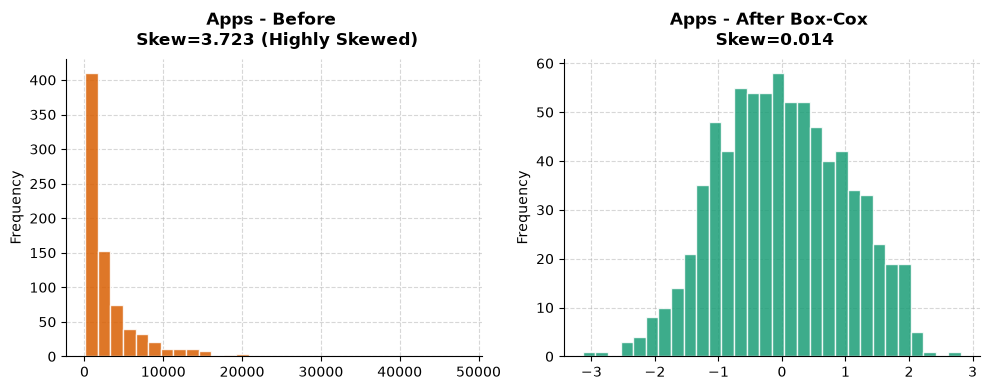

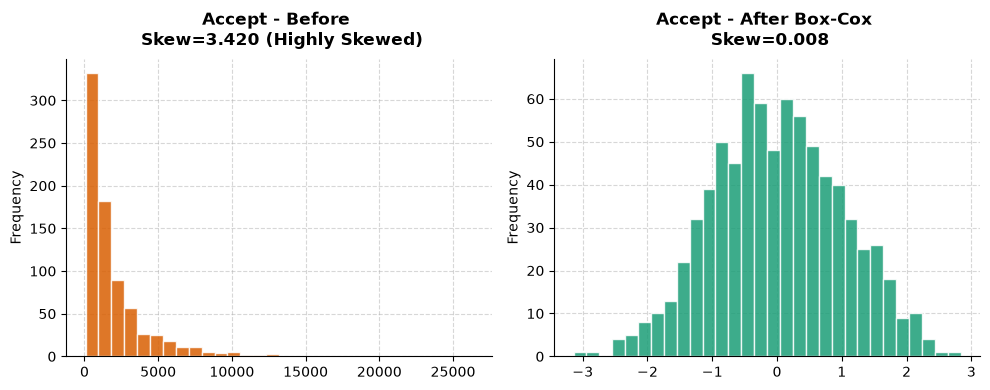

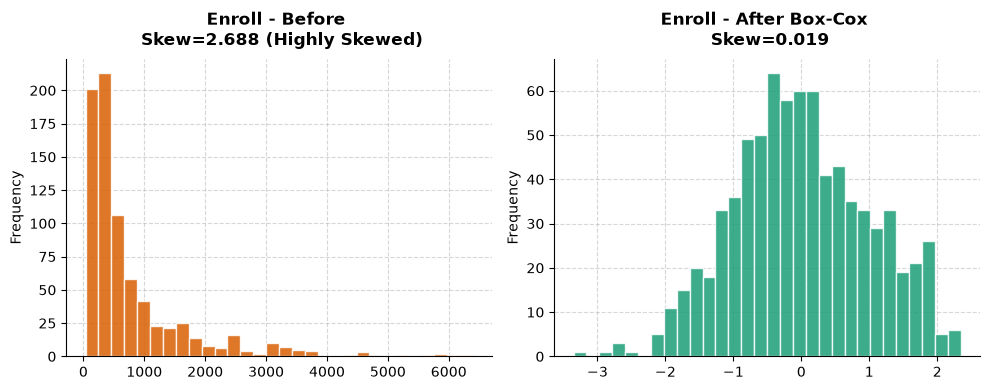

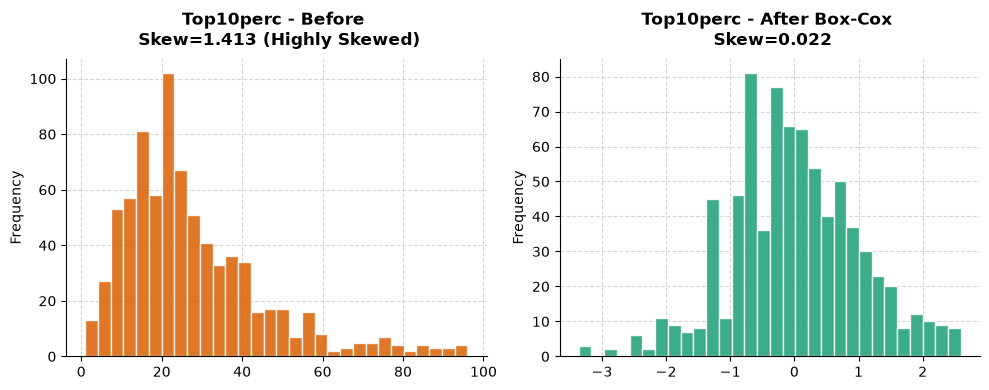

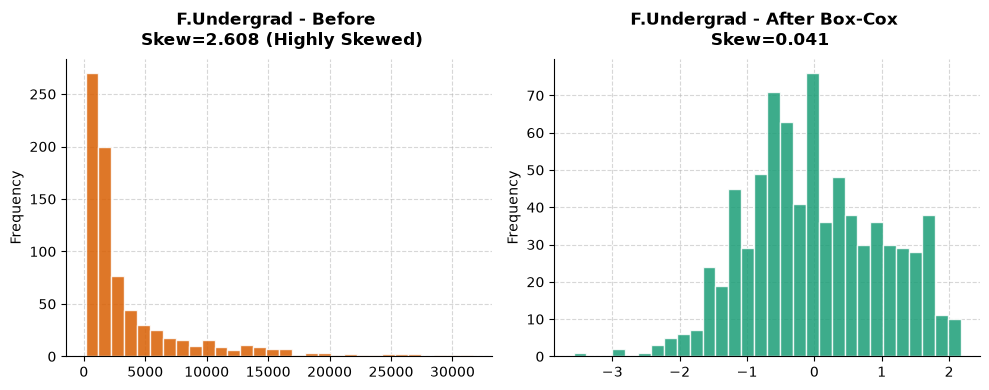

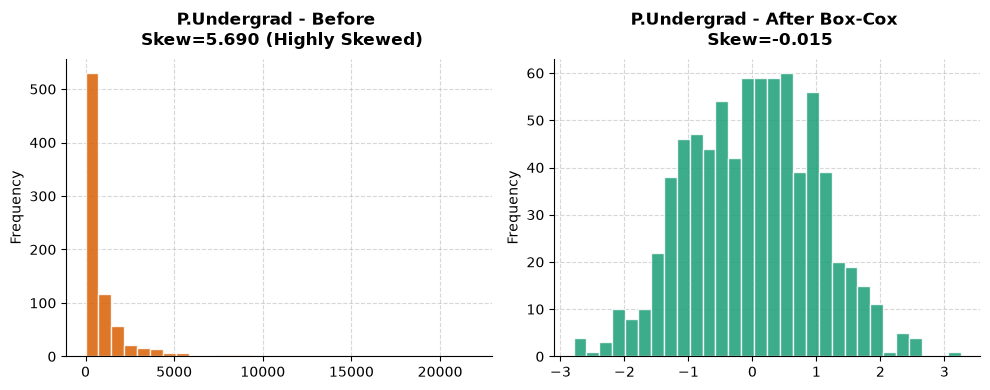

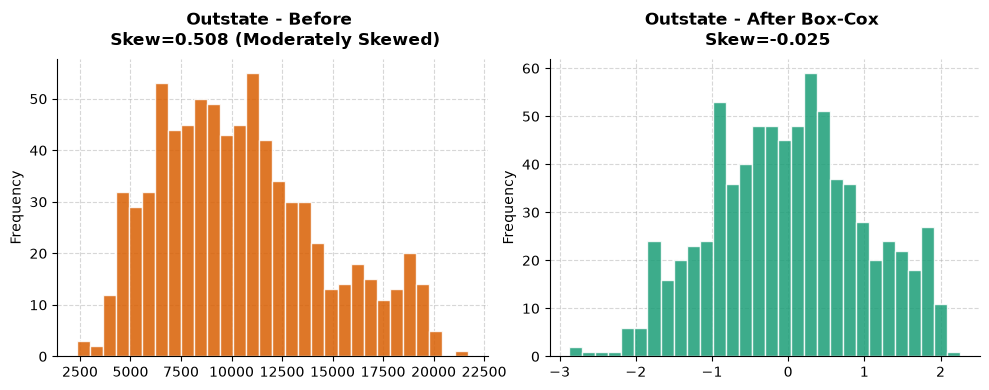

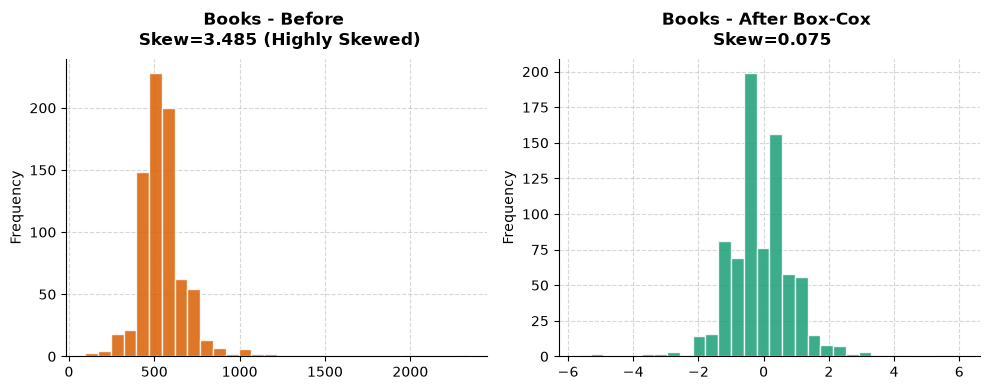

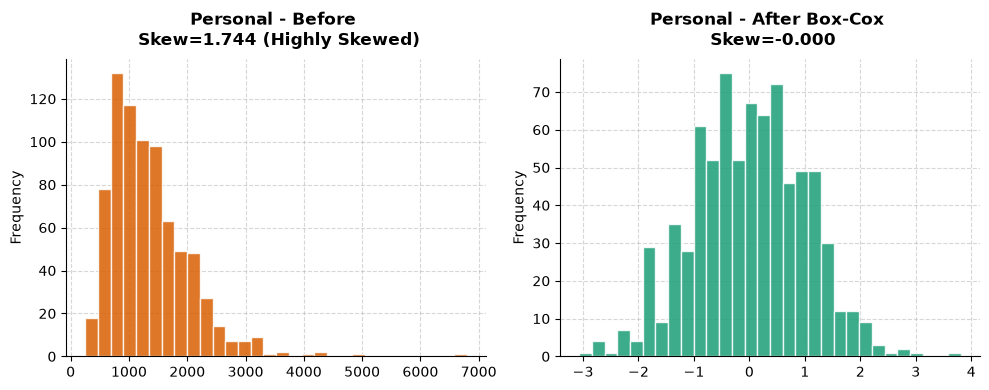

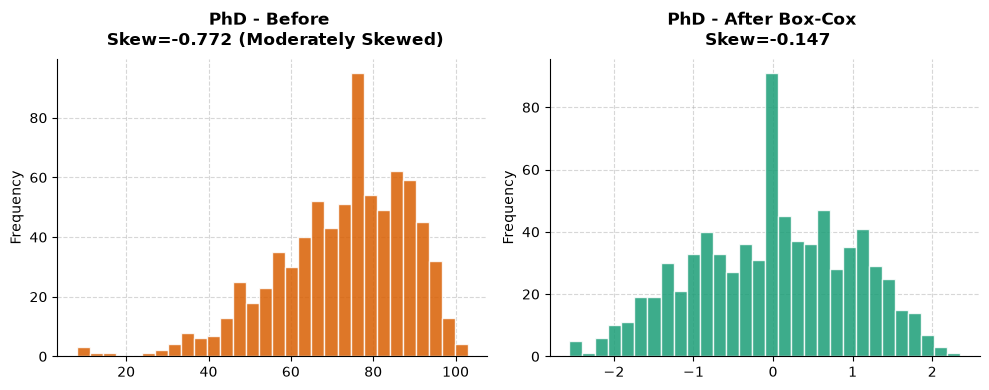

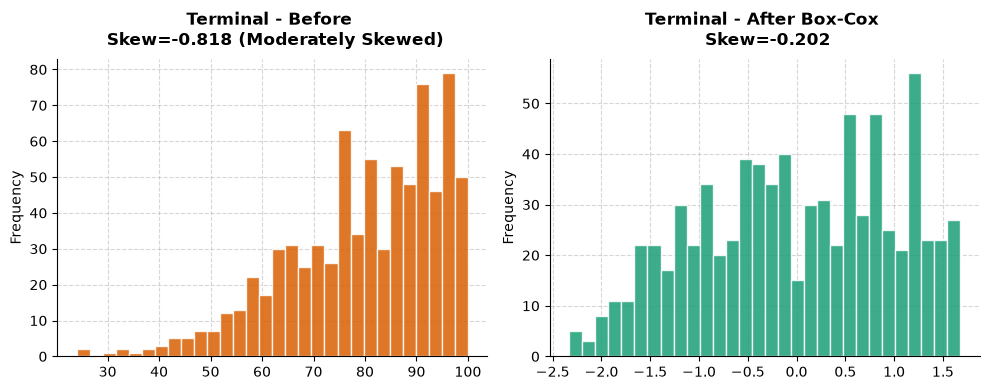

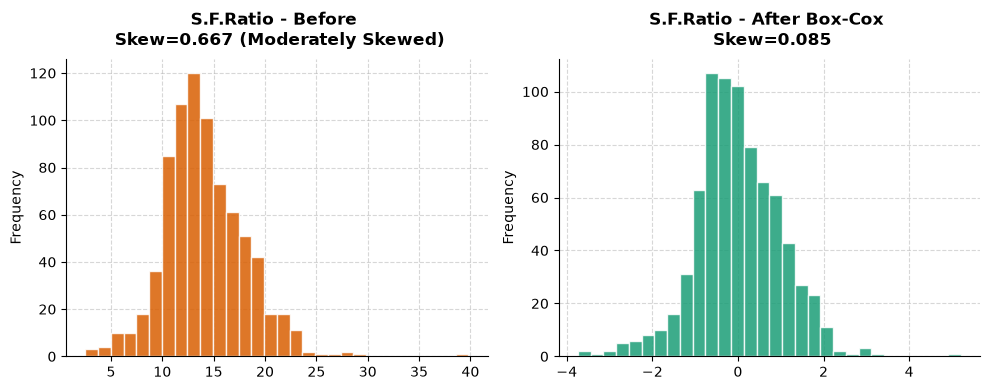

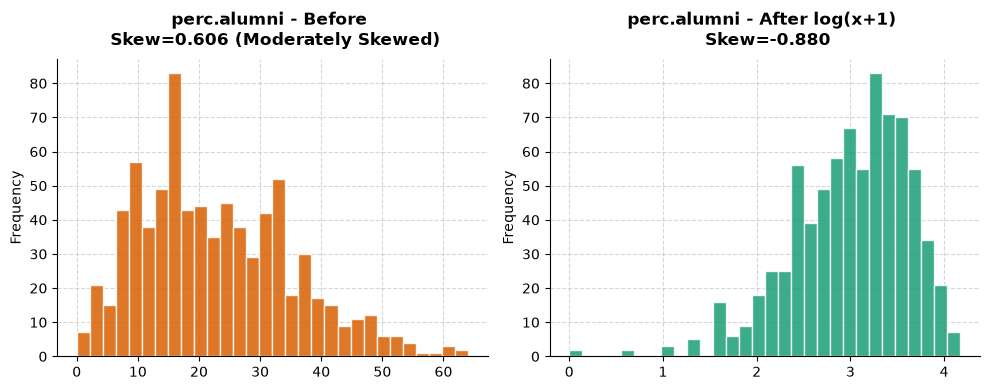

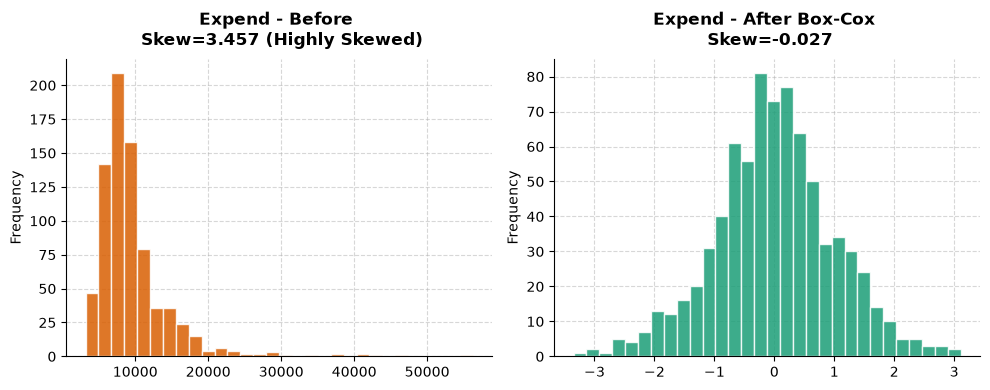

In [16]:
plot_transformations(df, skew_table)

In [17]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [18]:
trans_cols = []

for _, row in skew_table.iterrows():

    col = row['Feature']
    recommendation = row['Recommended Transformation']

    if recommendation == 'No Recomm':
        continue

    new_col = col + '_trans'

    if recommendation.startswith('Box-Cox'):
        pt = PowerTransformer(method='box-cox')
        df[new_col] = pt.fit_transform(df[[col]])

    elif recommendation.startswith('log'):
        df[new_col] = np.log1p(df[col])

    else:
        pt = PowerTransformer(method='yeo-johnson')
        df[new_col] = pt.fit_transform(df[[col]])

    trans_cols.append(new_col)

In [19]:
df[trans_cols].head(2)

,Apps_trans,Accept_trans,Enroll_trans,Top10perc_trans,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans
0,0.029312,0.042882,0.493366,-0.055201,0.432170,0.298275,-0.693239,-0.61331,1.270835,-0.293816,-0.285537,1.017429,2.564949,-0.491297
1,0.284347,0.487597,0.142440,-0.587168,0.363958,0.867168,0.555689,1.30222,0.454915,-2.192369,-2.252378,-0.434610,2.833213,0.551592


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [20]:
df['Accept_Rate'] = df['Accept'] / df['Apps']
df[['College', 'Apps', 'Accept', 'Accept_Rate']].head(2)

,College,Apps,Accept,Accept_Rate
0,Abilene Christian University,1660,1232,0.742169
1,Adelphi University,2186,1924,0.880146


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [21]:
df['Outstate_Tier'] = pd.cut(df['Outstate'], bins=4, labels=['Low', 'Medium', 'High', 'High 2'])
df['Outstate_Tier'].value_counts().sort_index(ascending = False)

Outstate_Tier
High 2     73
High      167
Medium    350
Low       186
Name: count, dtype: int64

#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [22]:
tier_map = {'Low': 0, 'Medium': 1, 'High': 2, 'High 2': 3}
df['Outstate_Tier_Code'] = df['Outstate_Tier'].map(tier_map).astype(int)
df[['Outstate', 'Outstate_Tier', 'Outstate_Tier_Code']].head()

,Outstate,Outstate_Tier,Outstate_Tier_Code
0,7440,Medium,1
1,12280,High,2
2,11250,Medium,1
3,12960,High,2
4,7560,Medium,1


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [23]:
private_map = {'Yes':1, 'No':0}
df['Private_Code'] = df['Private'].map(private_map).astype(int)
df[['College','Private','Private_Code']].head(2)

,College,Private,Private_Code
0,Abilene Christian University,Yes,1
1,Adelphi University,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [24]:
cols_to_scale = trans_cols + ['Accept_Rate', 'Outstate_Tier_Code', 'Private_Code']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[cols_to_scale])

scaled_cols = [col + '_scaled' for col in cols_to_scale]
df[scaled_cols] = scaled_values

df[scaled_cols]

,Apps_trans_scaled,Accept_trans_scaled,Enroll_trans_scaled,Top10perc_trans_scaled,F.Undergrad_trans_scaled,P.Undergrad_trans_scaled,Outstate_trans_scaled,Books_trans_scaled,Personal_trans_scaled,PhD_trans_scaled,Terminal_trans_scaled,S.F.Ratio_trans_scaled,perc.alumni_trans_scaled,Expend_trans_scaled,Accept_Rate_scaled,Outstate_Tier_Code_scaled,Private_Code_scaled
0,0.029312,0.042882,0.493366,-0.055201,0.432170,0.298275,-0.693239,-0.613310,1.270835,-0.293816,-0.285537,1.017429,-0.722160,-0.491297,-0.031097,-0.182476,0.613096
1,0.284347,0.487597,0.142440,-0.587168,0.363958,0.867168,0.555689,1.302220,0.454915,-2.192369,-2.252378,-0.434610,-0.284229,0.551592,0.907456,0.932495,0.613096
2,-0.112375,-0.075204,-0.315478,-0.123058,-0.637625,-0.730601,0.321561,-1.037466,-0.070995,-1.269008,-1.044865,-0.249854,0.696512,0.095868,0.146023,-0.182476,0.613096
3,-1.331842,-1.293538,-1.395388,1.614117,-1.530868,-0.977733,0.703268,-0.613310,-0.654868,1.361388,1.364692,-1.740755,1.028880,1.725944,0.613492,0.932495,0.613096
4,-2.153306,-2.288489,-2.657853,-0.587168,-2.586463,0.624001,-0.656593,1.553279,0.454915,0.113681,-0.690798,-0.515050,-3.115901,0.636236,0.066229,-0.182476,0.613096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,0.288949,0.250901,0.204023,-2.218249,0.495393,1.236882,-0.896522,-0.228424,-0.009910,-0.899614,-1.350428,1.661751,-0.488553,-1.978643,-0.388838,-1.297447,-1.631066
773,0.183382,0.424752,0.456592,0.010498,0.420447,0.793755,0.384252,0.450010,0.074553,-0.094191,-0.494731,-0.146034,0.748341,0.224201,1.187993,-0.182476,0.613096
774,0.246166,0.482991,0.456592,0.576057,0.401849,-0.434130,-0.863134,0.555383,-0.883270,-0.485191,-0.494731,0.133382,0.060726,-0.029826,1.132357,-1.297447,0.613096
775,1.659319,0.724135,1.067899,2.572207,0.950274,-0.828300,1.970529,0.634268,1.185821,1.709858,1.263108,-2.380358,1.476888,2.768052,-3.520789,2.047467,0.613096


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

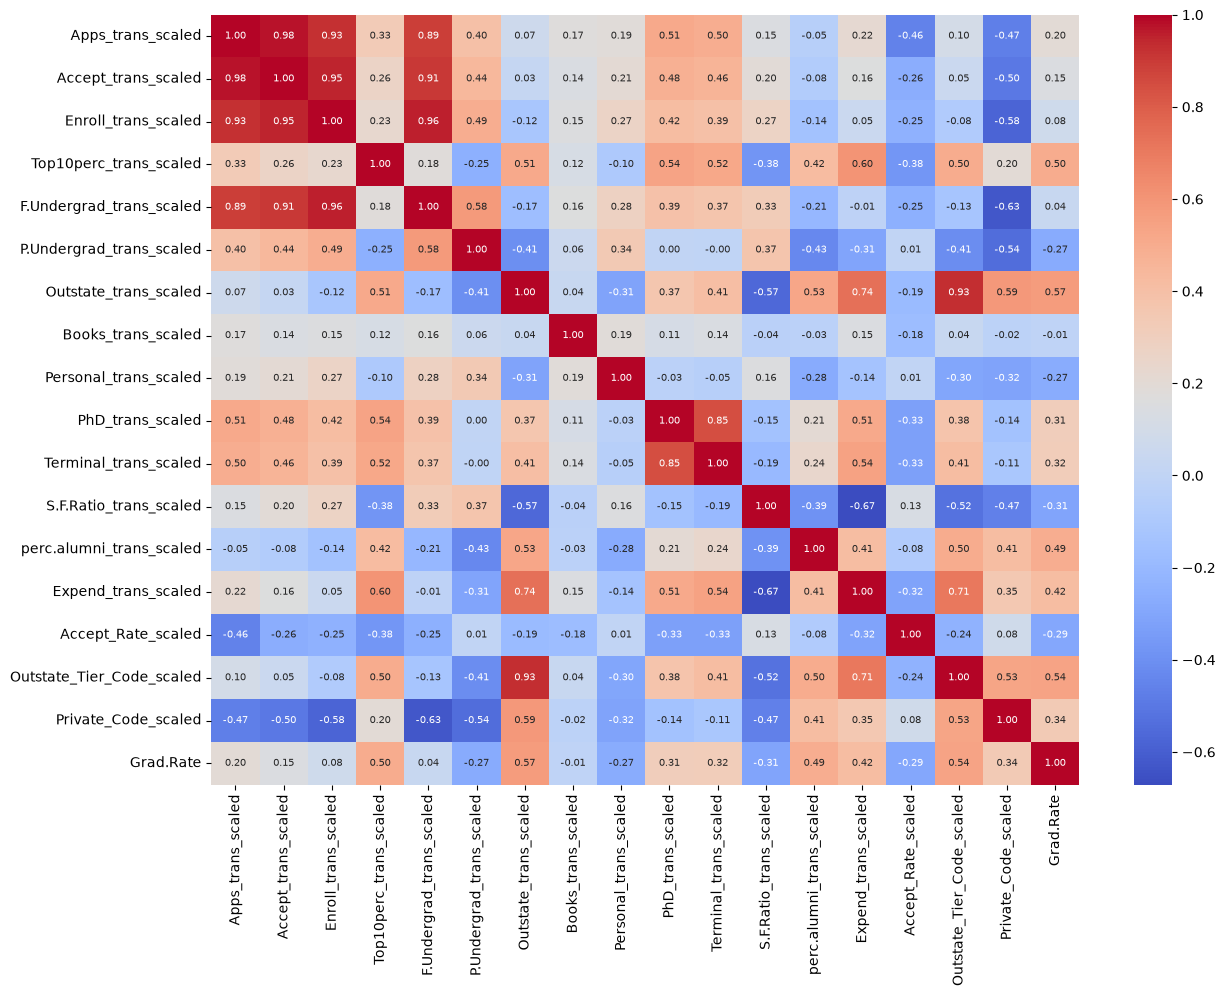

In [25]:
heat_cols = scaled_cols + ['Grad.Rate']
corr = df[heat_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 7})
plt.show()

In [26]:
corr['Grad.Rate'].sort_values(ascending=False)

Grad.Rate                    1.000000
Outstate_trans_scaled        0.570917
Outstate_Tier_Code_scaled    0.541930
Top10perc_trans_scaled       0.500982
perc.alumni_trans_scaled     0.491272
Expend_trans_scaled          0.418966
Private_Code_scaled          0.335860
Terminal_trans_scaled        0.316912
PhD_trans_scaled             0.311638
Apps_trans_scaled            0.200882
Accept_trans_scaled          0.145821
Enroll_trans_scaled          0.077974
F.Undergrad_trans_scaled     0.035055
Books_trans_scaled          -0.006663
Personal_trans_scaled       -0.266509
P.Undergrad_trans_scaled    -0.274919
Accept_Rate_scaled          -0.292830
S.F.Ratio_trans_scaled      -0.311915
Name: Grad.Rate, dtype: float64

In [27]:
corr_features = df[scaled_cols].corr().abs()
high_corr = corr_features[(corr_features > 0.9) & (corr_features < 1)].stack().dropna()
print(high_corr)

Apps_trans_scaled          Accept_trans_scaled          0.977006
                           Enroll_trans_scaled          0.927900
Accept_trans_scaled        Apps_trans_scaled            0.977006
                           Enroll_trans_scaled          0.948501
                           F.Undergrad_trans_scaled     0.906549
Enroll_trans_scaled        Apps_trans_scaled            0.927900
                           Accept_trans_scaled          0.948501
                           F.Undergrad_trans_scaled     0.956805
F.Undergrad_trans_scaled   Accept_trans_scaled          0.906549
                           Enroll_trans_scaled          0.956805
Outstate_trans_scaled      Outstate_Tier_Code_scaled    0.933955
Outstate_Tier_Code_scaled  Outstate_trans_scaled        0.933955
dtype: float64


In [28]:
df = df.drop(columns='Accept_trans_scaled')
df = df.drop(columns='Enroll_trans_scaled')
df = df.drop(columns='F.Undergrad_trans_scaled')
df = df.drop(columns='Outstate_Tier_Code_scaled')

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [29]:
untrans_features = ['Apps', 'Top10perc', 'P.Undergrad', 'Outstate', 'Books','Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend']
trans_features = ['Apps_trans', 'Top10perc_trans', 'P.Undergrad_trans', 'Outstate_trans', 'Books_trans','Personal_trans', 'PhD_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 'Expend_trans']

X = df[untrans_features]
X2 = df[trans_features]
y = df['Grad.Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.3, random_state=1)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
print(X2_train.shape, X2_test.shape)
print(y2_train.shape, y2_test.shape)

(543, 11) (233, 11)
(543,) (233,)
(543, 11) (233, 11)
(543,) (233,)


#### 15. Fit a linear regression using the raw predictors


In [30]:
lr = LinearRegression()
lr.fit(X_train, y_train)

r2_train = lr.score(X_train, y_train)
r2_test = lr.score(X_test, y_test)

print("r2 train:", r2_train)
print("r2 test:", r2_test)

r2 train: 0.4756456156865365
r2 test: 0.3438077659002585


#### 16. Fit the same model using the log-transformed predictors

In [31]:
lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)

r2_train2 = lr2.score(X2_train, y2_train)
r2_test2 = lr2.score(X2_test, y2_test)

print("r2 train:", r2_train2)
print("r2 test:", r2_test2)

r2 train: 0.48972482914898274
r2 test: 0.3344182262273694


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [32]:
print("Untransformed, train:", r2_train, " test:", r2_test)
print("Transformed, train:", r2_train2, " test:", r2_test2)

print("Difference:", r2_test2 - r2_test)

Untransformed, train: 0.4756456156865365  test: 0.3438077659002585
Transformed, train: 0.48972482914898274  test: 0.3344182262273694
Difference: -0.009389539672889136


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [33]:
df.to_csv('college_transformed.csv', index=False)